<a href="https://colab.research.google.com/github/prajwalthinking/dog-breed-classification/blob/main/DogClassifier_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project: Dog breed detector**

## **Import**

In [2]:
# Imports

import os
import sys
import numpy as np
import pandas as pd

import time
import json
from IPython.core.display import HTML
from matplotlib import pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.python.keras import backend as K
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras import layers
from tensorflow.keras import activations
from tensorflow.keras import optimizers
from tensorflow.keras import losses
from tensorflow.keras import initializers
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
# Import pretrained models
from tensorflow.keras.applications import ResNet50V2,VGG16, InceptionV3, MobileNetV2, DenseNet121

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import xml.etree.ElementTree as ET # for parsing XML
from PIL import Image # to read images
import tensorflow_datasets as tfds
#import tensorflow_addons as tfa

In [2]:
!pip uninstall -y tensorflow tensorflow-addons keras
!pip install tensorflow==2.12.0 tensorflow_addons==0.23.0

Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Found existing installation: keras 3.8.0
Uninstalling keras-3.8.0:
  Successfully uninstalled keras-3.8.0
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 26.2 MB/s eta 0:00:00
   ━━━━━━

In [3]:
# https://www.tensorflow.org/guide/data_performance
AUTOTUNE = tf.data.experimental.AUTOTUNE

In [4]:
print("tensorflow version", tf.__version__)
print("keras version", tf.keras.__version__)

tensorflow version 2.12.0
keras version 2.12.0


## **Test GPU + RAM**

In [5]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Select the Runtime > "Change runtime type" menu to enable a GPU accelerator, ')
  print('and then re-execute this cell.')
else:
  print(gpu_info)


from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('To enable a high-RAM runtime, select the Runtime > "Change runtime type"')
  print('menu, and then select High-RAM in the Runtime shape dropdown. Then, ')
  print('re-execute this cell.')
else:
  print('You are using a high-RAM runtime!')

Mon Apr 14 03:09:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **Dog DataSet**

In [6]:
!rm -rf DatasetStore

In [7]:
import requests
import tarfile
dataset_path = "DatasetStore"

# Download and extract dataset
if not os.path.exists(dataset_path):
  os.mkdir(dataset_path)
  packet_url = "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar"
  packet_file = os.path.basename(packet_url)
  packet_file = os.path.join(dataset_path, packet_file)
  with requests.get(packet_url, stream=True) as r:
      r.raise_for_status()
      with open(packet_file, 'wb') as f:
          for chunk in r.iter_content(chunk_size=8192):
              f.write(chunk)

  with tarfile.open(packet_file) as tfile:
    tfile.extractall(dataset_path)

  packet_url = "http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar"
  packet_file = os.path.basename(packet_url)
  packet_file = os.path.join(dataset_path, packet_file)
  with requests.get(packet_url, stream=True) as r:
      r.raise_for_status()
      with open(packet_file, 'wb') as f:
          for chunk in r.iter_content(chunk_size=8192):
              f.write(chunk)

  with tarfile.open(packet_file) as tfile:
    tfile.extractall(dataset_path)

**Display some training images**

---



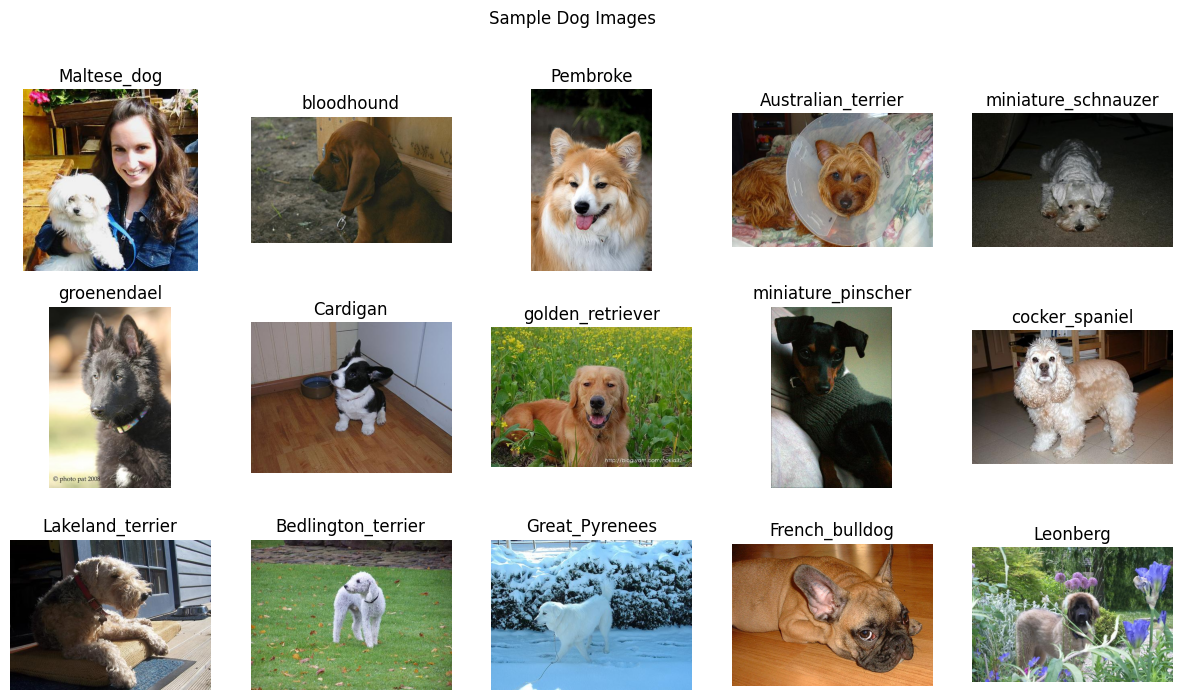

In [8]:
# https://www.kaggle.com/gtimoshaz/dataset-reading-demo

breed_list = os.listdir('DatasetStore/Annotation/') # list of all breeds for further demo

# Train images
fig = plt.figure(figsize=(15,8))
for i in range(15):
    axs = fig.add_subplot(3,5,i+1)
    breed = np.random.choice(breed_list) # random breed
    dog = np.random.choice(os.listdir('DatasetStore/Annotation/' + breed)) # random image
    img = Image.open('DatasetStore/Images/' + breed + '/' + dog + '.jpg')
    tree = ET.parse('DatasetStore/Annotation/' + breed + '/' + dog) # init parser for file given
    root = tree.getroot()
    object_1 = root.findall('object')[0]; # finding all dogs. An array
    name = object_1.find('name').text;
    axs.set_title(name)
    plt.imshow(img)
    plt.axis('off')

plt.suptitle("Sample Dog Images")
plt.show()

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from PIL import Image
import xml.etree.ElementTree as ET

# Parameters
image_size = 150  # Resized image dimensions
dataset_path = 'DatasetStore'
image_dir = os.path.join(dataset_path, 'Images')
annotation_dir = os.path.join(dataset_path, 'Annotation')
breed_list = sorted(os.listdir(annotation_dir))
num_classes = len(breed_list)

# Create label mapping
label_map = {breed: i for i, breed in enumerate(breed_list)}

# Function to crop dog face using annotation
def crop_dog_face(img_path, annot_path):
    tree = ET.parse(annot_path)
    root = tree.getroot()
    object_tag = root.find('object')
    if object_tag is None: return None
    bndbox = object_tag.find('bndbox')
    xmin = int(bndbox.find('xmin').text)
    ymin = int(bndbox.find('ymin').text)
    xmax = int(bndbox.find('xmax').text)
    ymax = int(bndbox.find('ymax').text)

    img = Image.open(img_path)
    img = img.crop((xmin, ymin, xmax, ymax))
    img = img.resize((image_size, image_size))
    return np.array(img)

# Load and preprocess data (this will take time)
X, y = [], []

for breed in breed_list:
    img_files = os.listdir(os.path.join(image_dir, breed))
    for img_file in img_files[:30]:  # Limit to 30 per class for speed
        img_path = os.path.join(image_dir, breed, img_file)
        annot_path = os.path.join(annotation_dir, breed, img_file.replace('.jpg', ''))
        try:
            cropped_img = crop_dog_face(img_path, annot_path)
            if cropped_img is not None and cropped_img.shape == (image_size, image_size, 3):
                X.append(cropped_img)
                y.append(label_map[breed])
        except:
            continue

X = np.array(X) / 255.0
y = to_categorical(y, num_classes=num_classes)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(image_size, image_size, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 17, 17, 128)      0

In [10]:
print(f"Number of breeds found: {len(breed_list)}")
print("Sample breed names:", breed_list[:5])


Number of breeds found: 120
Sample breed names: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu']


In [11]:
print(f"Total images loaded: {len(X)}")
print(f"Total labels loaded: {len(y)}")


Total images loaded: 3599
Total labels loaded: 3599


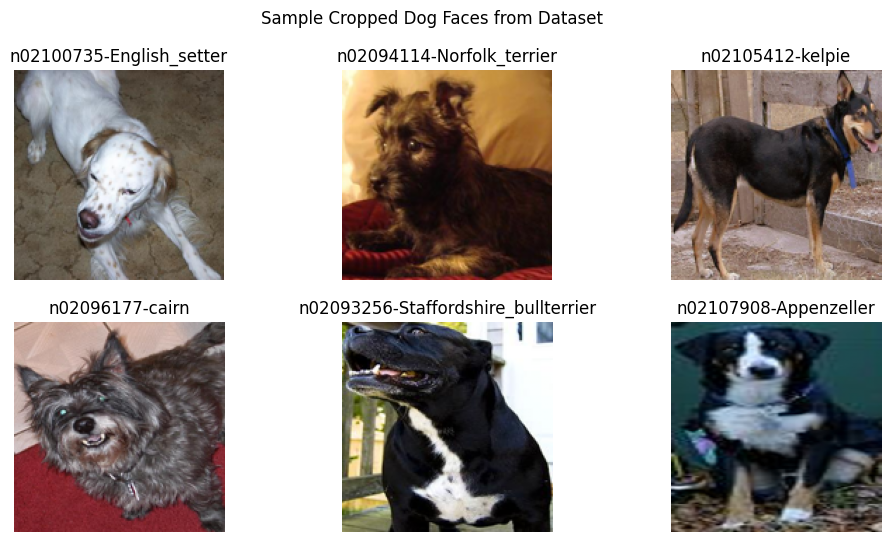

In [12]:
# Visual check
plt.figure(figsize=(12, 6))
for i in range(6):
    idx = np.random.randint(len(X))
    img = X[idx]
    label_index = np.argmax(y[idx])
    breed_name = breed_list[label_index]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(breed_name)
    plt.axis('off')
plt.suptitle("Sample Cropped Dog Faces from Dataset")
plt.show()


1/1 [==============================] - 0s 103ms/step
Predicted breed: n02086646-Blenheim_spaniel (99.60%)


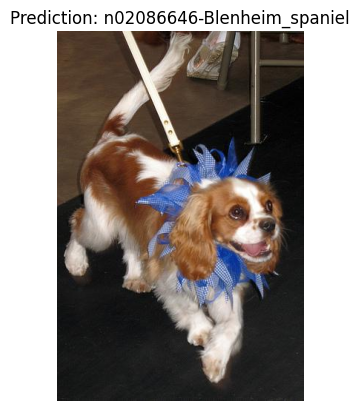

In [13]:
# Function to predict breed from a file path
def predict_dog_breed(img_path, annot_path):
    img = crop_dog_face(img_path, annot_path)
    if img is None:
        print("No object found in annotation.")
        return
    img = img / 255.0
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    prediction = model.predict(img)
    predicted_index = np.argmax(prediction)
    predicted_breed = breed_list[predicted_index]
    confidence = np.max(prediction)

    print(f"Predicted breed: {predicted_breed} ({confidence*100:.2f}%)")

    # Visualize
    plt.imshow(Image.open(img_path))
    plt.title(f"Prediction: {predicted_breed}")
    plt.axis('off')
    plt.show()

# Example usage
test_breed = breed_list[5]
test_img_file = os.listdir(os.path.join(image_dir, test_breed))[0]
img_path = os.path.join(image_dir, test_breed, test_img_file)
annot_path = os.path.join(annotation_dir, test_breed, test_img_file.replace('.jpg', ''))
predict_dog_breed(img_path, annot_path)


In [14]:
def predict_dog_breed(img_path, annot_path, actual_breed=None):
    img = crop_dog_face(img_path, annot_path)
    if img is None:
        print("No object found in annotation.")
        return
    img = img / 255.0
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    prediction = model.predict(img)
    predicted_index = np.argmax(prediction)
    predicted_breed = breed_list[predicted_index]
    confidence = np.max(prediction)

    # Print predicted and actual
    print(f"✅ Predicted breed: {predicted_breed} ({confidence*100:.2f}%)")
    if actual_breed:
        print(f"📌 Actual breed: {actual_breed}")
        result = "✔️ Correct" if predicted_breed == actual_breed else "❌ Incorrect"
        print(f"Result: {result}")

    # Visualize
    plt.imshow(Image.open(img_path))
    plt.title(f"Predicted: {predicted_breed}\nActual: {actual_breed}")
    plt.axis('off')
    plt.show()


1/1 [==============================] - 0s 51ms/step
✅ Predicted breed: n02086079-Pekinese (53.44%)
📌 Actual breed: n02086079-Pekinese
Result: ✔️ Correct


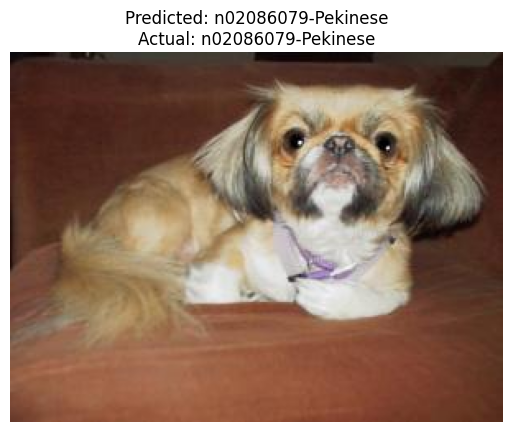

In [15]:
test_breed = breed_list[3]  # You can change this index to try other breeds
test_img_file = os.listdir(os.path.join(image_dir, test_breed))[0]
img_path = os.path.join(image_dir, test_breed, test_img_file)
annot_path = os.path.join(annotation_dir, test_breed, test_img_file.replace('.jpg', ''))

predict_dog_breed(img_path, annot_path, actual_breed=test_breed)


In [16]:
from google.colab import drive
drive.mount('/home')


Mounted at /home


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
# Save model locally in Colab
model.save("/content/drive/My Drive/Dog_classifier/dog_breed_cnn_model.h5")


In [19]:
from tensorflow.keras.models import load_model

# Load model
model_path = "/content/drive/My Drive/Dog_classifier/dog_breed_cnn_model.h5"
model = load_model(model_path)
print("✅ Model loaded successfully!")


✅ Model loaded successfully!


1/1 [==============================] - 0s 122ms/step
✅ Predicted breed: n02086646-Blenheim_spaniel (99.60%)
📌 Actual breed: n02086646-Blenheim_spaniel
Result: ✔️ Correct


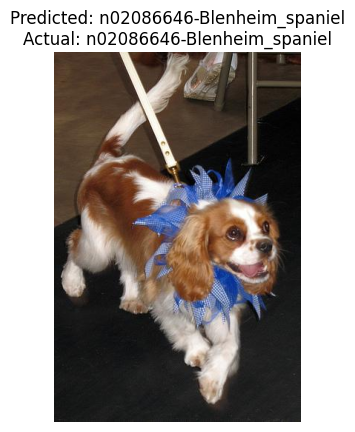

In [20]:
test_breed = breed_list[5]  # Pick another index to test different breed
test_img_file = os.listdir(os.path.join(image_dir, test_breed))[0]
img_path = os.path.join(image_dir, test_breed, test_img_file)
annot_path = os.path.join(annotation_dir, test_breed, test_img_file.replace('.jpg', ''))

predict_dog_breed(img_path, annot_path, actual_breed=test_breed)


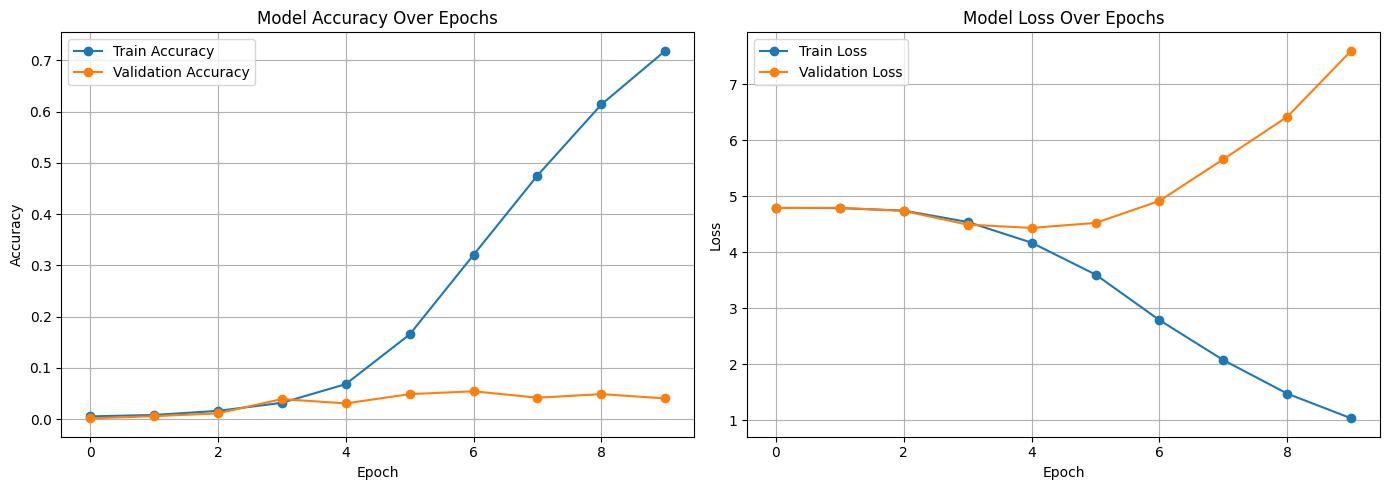

In [21]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [33]:
import gradio as gr
import tensorflow as tf
import numpy as np
import os
from PIL import Image

# Load model and labels
model = tf.keras.models.load_model("/content/drive/My Drive/Dog_classifier/dog_breed_cnn_model.h5")

# Load breed labels (replace with your actual label loading logic)
dataset_path = "DatasetStore/Annotation"
breed_list = sorted(os.listdir(dataset_path))  # Get sorted list of breeds

# Preprocessing function (MUST match training preprocessing)
def preprocess_image(image):
    # Convert to RGB if needed
    if image.mode != 'RGB':
        image = image.convert('RGB')

    # Resize to match model's expected input
    image = image.resize((150, 150))  # Should match your model's input size

    # Normalize and add batch dimension
    image_array = np.array(image) / 255.0
    return np.expand_dims(image_array, axis=0)

# Prediction function with error handling
def predict(image):
    try:
        processed_img = preprocess_image(image)
        prediction = model.predict(processed_img)
        top_3_indices = np.argsort(prediction[0])[::-1][:3]

        # Return dictionary with probabilities
        return {
            breed_list[i]: float(prediction[0][i])
            for i in top_3_indices
        }
    except Exception as e:
        return f"Error: {str(e)}"

# Create Gradio interface
gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload Dog Image"),
    outputs=gr.Label(num_top_classes=3, label="Top Predictions"),
    title="Dog Breed Classifier 🐶",
    description="Upload a clear photo of a dog's face for breed prediction"
).launch()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://64cfd0983255b74015.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
!pip install gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 6.0 MB/s eta 0:00:00
